In [ ]:
!pip install tensorflow

!pip install keras

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Device check (GPU recommended)
print(f"Using TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")

# Data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2  # If no separate val folder; adjust if using separate
)

val_datagen = ImageDataGenerator(rescale=1./255)

# from google.colab import files
# uploaded = files.upload()

# Load data (adjust paths; target_size=224 for VGG)
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',  # Or root if using validation_split
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',  # For binary: 2 classes, one-hot
    # subset='training' if train_datagen.validation_split > 0 else None
)

val_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/valid',  # Or same root with subset='validation'
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

num_classes = 2
class_names = list(train_generator.class_indices.keys())  # e.g., ['aa', 'healthy']
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

Using TensorFlow version: 2.19.0
GPUs available: 1
Found 771 images belonging to 2 classes.
Found 165 images belonging to 2 classes.


In [3]:
# Load pre-trained VGG16 (weights='imagenet')
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
base_model.trainable = False

# Add custom top for binary classification
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)  # Softmax for multi-class (binary ok)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # For one-hot labels
    metrics=['accuracy']
)

model.summary()  # Optional: View architecture


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,561,282 (105.14 MB)

 Trainable params: 12,846,594 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 819ms/step - accuracy: 0.9858 - loss: 0.0398 - val_accuracy: 1.0000 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 35s 720ms/step - accuracy: 0.9852 - loss: 0.0431 - val_accuracy: 0.9937 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.9937 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 729ms/step - accuracy: 0.9882 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 704ms/step - accuracy: 0.9793 - loss: 0.0362 

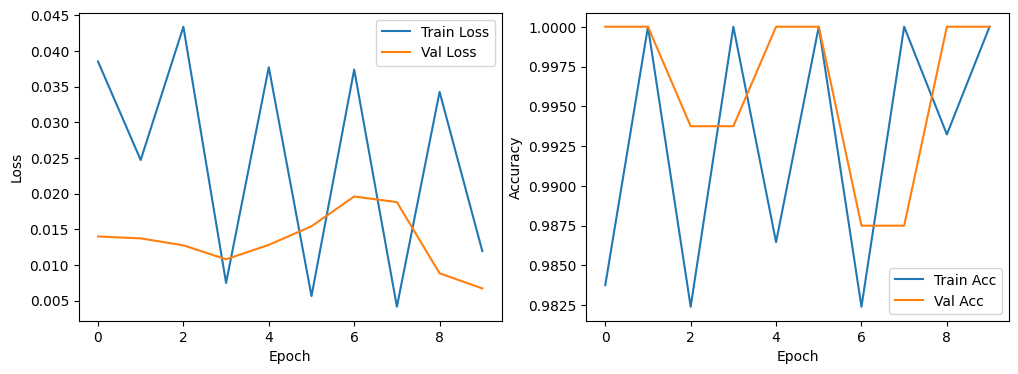

In [5]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7)

# Train
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[early_stop, lr_reducer]
)

# Plot curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
# Evaluate on validation
# val_preds = model.predict(val_generator, steps=validation_steps)
# val_labels = val_generator.classes
# val_pred_classes = np.argmax(val_preds, axis=1)

# Collect all predictions and labels from the validation generator
val_labels = []
val_preds = []
for _ in range(len(val_generator)):
    images, labels = next(val_generator)
    preds = model.predict(images, verbose=0)  # Set verbose to 0 to avoid printing progress for each batch
    val_labels.extend(np.argmax(labels, axis=1))
    val_preds.extend(np.argmax(preds, axis=1))

val_acc = accuracy_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds, average='weighted')
print(f'Validation Accuracy: {val_acc:.4f}, F1-Score: {val_f1:.4f}')

# Save model
model.save('vgg_aa_classifier_tf.h5')
from tensorflow.keras.preprocessing import image
# Inference on single image
def predict_image(image_path, model, class_names):

    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_class = np.argmax(preds[0])
    confidence = preds[0][predicted_class]

    return class_names[predicted_class], confidence

# Usage
pred_class, confidence = predict_image('/content/drive/MyDrive/test/Alopecia_Areata/alopecia_areata_0724_jpg.rf.fcc0c7b0af22cf09732d014f5989e4d1.jpg', model, class_names)
print(f'Prediction: {pred_class} (Confidence: {confidence:.4f})')

Validation Accuracy: 1.0000, F1-Score: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Alopecia_Areata (Confidence: 0.9988)
